# Машинное обучение, DS-поток
## Задание ML.9

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  190 баллов.

**ДЗ будет дополнено!**

In [ ]:
# Bot check

# HW_ID: ds_ml9
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
!pip install pytorch-lightning wandb --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 65.0 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.22.2
    Uninstalling wandb-0.22.2:
      Successfully uninstalled wandb-0.22.2


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from shutil import copyfile
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision import transforms
import torchvision

import wandb
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback, ModelCheckpoint

device = f"cuda" if torch.cuda.is_available() else "cpu"
from torchmetrics.functional import accuracy
from torchmetrics import F1Score
from torch.utils.data import Subset
from torchvision.models import resnet50
from sklearn.metrics import classification_report

In [3]:
sns.set(style='darkgrid', palette='Set2')
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nekirill2015 (nekirill2015-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

---
### Инструкция Pytorch Lightning + WandB

Это задание нужно выполнять, используя Pytorch Lightning совместно с WandB.

1. Обучение каждой из моделей должно идти с отдельным запуском в WandB. Если вы закончили всю работу с данной моделью (включая тестирование), не забывайте завершать запуск с помощью `wandb.finish()`.


2. **Важно**: Делать скрины с [wandb.ai](https://wandb.ai) и вставлять ссылки на [wandb.ai](https://wandb.ai) крайне не приветствуется и может караться. Не создавайте ссылок на ваш проект &mdash; он должен быть приватным! Вместо этого, смотрите пункт [Визуализация запусков и выводы](#vis).

3. Если вы сделали задание только частично, все равно визуализируйте имеющиеся запуски в пункте [Визуализация запусков и выводы](#vis).





### Задача 1. Transfer learning
Вы научите нейронную сеть классифицировать произведения искусства различных художников, т.е. определять к какому художнику относится картина.

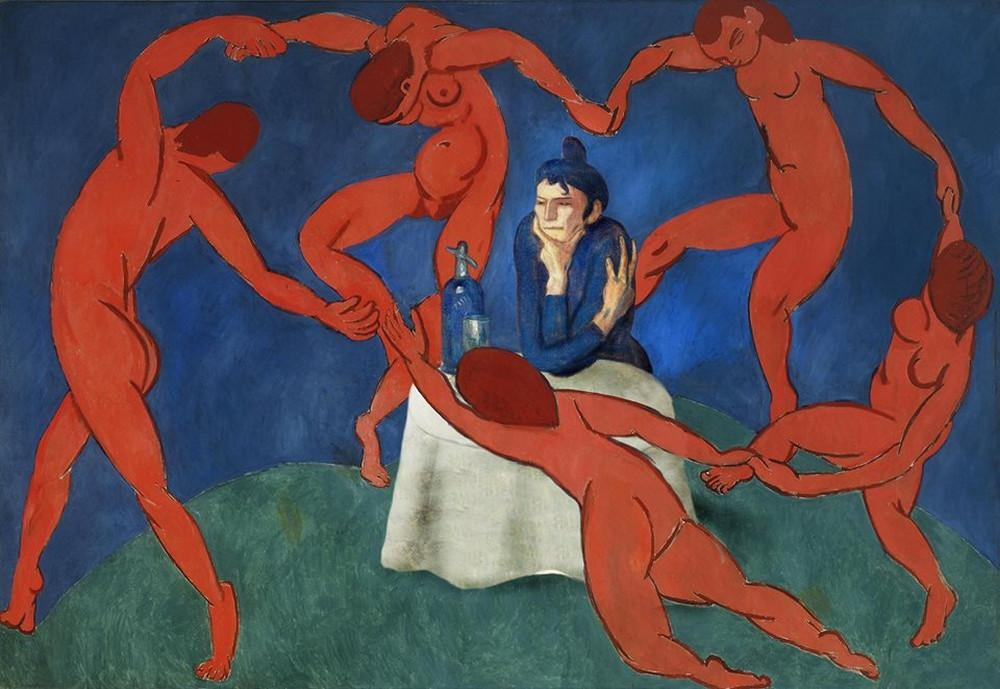

#### 1. Данные
Скачайте архив с датасетом по [ссылке](https://disk.yandex.ru/d/_BUueJa4RVXplQ).

Если вы работаете в **Google Colab**, то удобнее всего будет скачать архив на Google Drive (диск). В таком случае не придется загружать архив вручную каждый раз, когда обрывается runtime. Для этого перейдите в левую  боковую панель, нажмите на кнопку с папочкой, а затем на кнопку с папочкой с изображением Google Drive. Теперь все файлы с диска доступны по пути `drive/MyDrive/`.

Если вы работаете в **Kaggle**, то для того, чтобы загрузить данные, перейдите в правую боковую панель. В разделе `Data` возле кнопки `Add Data` расположена кнопка загрузки данных. Нажмите на нее, появится панель `Create a New Dataset`. Назовите новый датасет. Загрузите туда архив.  После того, как датасет будет проверен, он появится у вас в датасетах. Для того, чтобы начать с ним работать в ноутбуке в Kaggle, нужно снова перейти в раздел `Data` и нажать `Add Data`. Затем нажмите кнопку `Your Datasets` и нажмите на плюс возле вашего датасета. После этого датасет появится в разделе `Data`. Причем **Kaggle** разархивирует данные за вас.

Для того, чтобы разархивировать данные, выполните следующие действия.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Запишите путь до архива.
zip_path = '/content/drive/MyDrive/artworks.zip'
# Замените пробелы в пути, чтобы следующая bash-команда работала корректно.
zip_path_bash = str(zip_path).replace(' ', '\ ')
# Разархивируйте файлы.
!unzip $zip_path_bash -d .
# Укажите путь до данных.
data_path = Path('./artworks')

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1723949711.py:4: SyntaxWarning: invalid escape sequence '\ '
  zip_path_bash = str(zip_path).replace(' ', '\ ')


Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_472.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_265.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_122.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_636.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_328.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_166.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_203.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_577.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_649.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_429.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_518.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_348.jpg  
  inflating: ./artworks/images/train/Edgar_Degas/Edgar_Degas_216.jpg  
  inflati

Данные содержат папку с изображениями `images` и таблицу с основной информацией про художников `artists.csv`. Папка `images` в свою очередь состоит из папок `train` и `test` с обучающим и тестовым наборами данных соответственно. Рассмотрим, например, папку с тренировочным набором данных.

In [ ]:
sorted((data_path / 'images' / 'train').iterdir())

[PosixPath('artworks/images/train/Albrecht_Durer'),
 PosixPath('artworks/images/train/Alfred_Sisley'),
 PosixPath('artworks/images/train/Amedeo_Modigliani'),
 PosixPath('artworks/images/train/Andrei_Rublev'),
 PosixPath('artworks/images/train/Andy_Warhol'),
 PosixPath('artworks/images/train/Camille_Pissarro'),
 PosixPath('artworks/images/train/Caravaggio'),
 PosixPath('artworks/images/train/Claude_Monet'),
 PosixPath('artworks/images/train/Diego_Rivera'),
 PosixPath('artworks/images/train/Diego_Velazquez'),
 PosixPath('artworks/images/train/Edgar_Degas'),
 PosixPath('artworks/images/train/Edouard_Manet'),
 PosixPath('artworks/images/train/Edvard_Munch'),
 PosixPath('artworks/images/train/El_Greco'),
 PosixPath('artworks/images/train/Eugene_Delacroix'),
 PosixPath('artworks/images/train/Francisco_Goya'),
 PosixPath('artworks/images/train/Frida_Kahlo'),
 PosixPath('artworks/images/train/Georges_Seurat'),
 PosixPath('artworks/images/train/Giotto_di_Bondone'),
 PosixPath('artworks/images/t

Она содержит папки, соответствующие художникам в датасете. В каждой такой папке находится тренировочный набор картин художника.

In [ ]:
sorted((data_path / 'images' / 'train' / 'Albrecht_Durer').iterdir())

[PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_001.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_002.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_004.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_005.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_006.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_007.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_008.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_010.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_011.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_012.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_013.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_016.jpg'),
 PosixPath('artworks/images/train/Albrecht_Durer/Albrecht_Durer_018.jpg'),
 PosixPath('artworks/imag

Приведем примеры изображений.

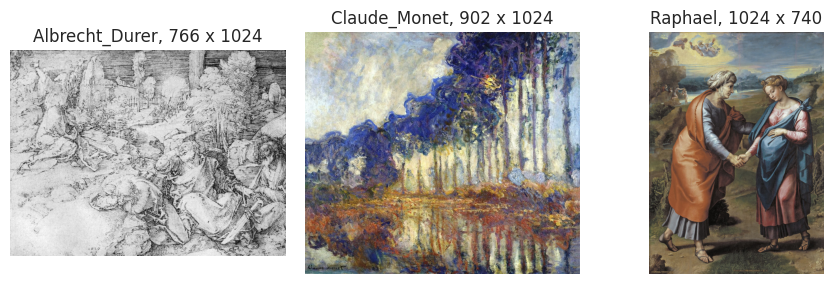

In [ ]:
images_paths = [
    data_path / 'images' / 'train' / 'Albrecht_Durer' / 'Albrecht_Durer_310.jpg',
    data_path / 'images' / 'train' / 'Claude_Monet' / 'Claude_Monet_007.jpg',
    data_path / 'images' / 'train' / 'Raphael' / 'Raphael_100.jpg'
]
plt.figure(figsize=(9, 3))
for i, image_path in enumerate(images_paths):
    author = image_path.parent.name
    plt.subplot(1, 3, i + 1)
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.title(f'{author}, {image.shape[0]} x {image.shape[1]}')
    plt.axis("off")
plt.tight_layout()

Заметьте, что все картины разных пропорций и размеров, это нужно учесть при обучении модели. Чтобы привести картины к одному размеру, можно использовать аугментации, см. пример с Симпсонами в семинаре.


Теперь посмотрим на таблицу с характеристиками художников.



In [9]:
artists = pd.read_csv(data_path / 'artists.csv')
artists

,name,years,genre,nationality,bio,wikipedia,paintings
0,Amedeo Modigliani,1884 - 1920,Expressionism,Italian,Amedeo Clemente Modigliani (Italian pronunciat...,http://en.wikipedia.org/wiki/Amedeo_Modigliani,193
1,Vasiliy Kandinskiy,1866 - 1944,"Expressionism,Abstractionism",Russian,Wassily Wassilyevich Kandinsky (Russian: Васи́...,http://en.wikipedia.org/wiki/Wassily_Kandinsky,88
2,Diego Rivera,1886 - 1957,"Social Realism,Muralism",Mexican,Diego María de la Concepción Juan Nepomuceno E...,http://en.wikipedia.org/wiki/Diego_Rivera,70
3,Claude Monet,1840 - 1926,Impressionism,French,Oscar-Claude Monet (; French: [klod mɔnɛ]; 14 ...,http://en.wikipedia.org/wiki/Claude_Monet,73
4,Rene Magritte,1898 - 1967,"Surrealism,Impressionism",Belgian,René François Ghislain Magritte (French: [ʁəne...,http://en.wikipedia.org/wiki/René_Magritte,194
5,Salvador Dali,1904 - 1989,Surrealism,Spanish,Salvador Domingo Felipe Jacinto Dalí i Domènec...,http://en.wikipedia.org/wiki/Salvador_Dalí,139
6,Edouard Manet,1832 - 1883,"Realism,Impressionism",French,Édouard Manet (US: ; UK: ; French: [edwaʁ manɛ...,http://en.wikipedia.org/wiki/Édouard_Manet,90
7,Andrei Rublev,1360 - 1430,Byzantine Art,Russian,"Andrei Rublev (Russian: Андре́й Рублёв, IPA: [...",http://en.wikipedia.org/wiki/Andrei_Rublev,99
8,Vincent van Gogh,1853 – 1890,Post-Impressionism,Dutch,Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪl...,http://en.wikipedia.org/wiki/Vincent_van_Gogh,877
9,Gustav Klimt,1862 - 1918,"Symbolism,Art Nouveau",Austrian,"Gustav Klimt (July 14, 1862 – February 6, 1918...",http://en.wikipedia.org/wiki/Gustav_Klimt,117


Наша цель &mdash; построить классификатор картин по художникам. В колонке `paintings` указано общее число картин для каждого художника. Можно заметить большую несбалансированность классов. Поэтому в начале мы будем работать с художниками, для которых в сумме представлено не менее 200 картин.

In [ ]:
artists = artists.loc[artists.loc[:, 'paintings'] >= 200, :]
artists

,name,years,genre,nationality,bio,wikipedia,paintings
8,Vincent van Gogh,1853 – 1890,Post-Impressionism,Dutch,Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪl...,http://en.wikipedia.org/wiki/Vincent_van_Gogh,877
13,Pablo Picasso,1881 - 1973,Cubism,Spanish,Pablo Ruiz Picasso (; Spanish: [ˈpaβlo piˈkaso...,http://en.wikipedia.org/wiki/Pablo_Picasso,439
15,Pierre-Auguste Renoir,1841 - 1919,Impressionism,French,"Pierre-Auguste Renoir, commonly known as Augus...",http://en.wikipedia.org/wiki/Pierre-Auguste_Re...,336
16,Francisco Goya,1746 - 1828,Romanticism,Spanish,Francisco José de Goya y Lucientes (; Spanish:...,http://en.wikipedia.org/wiki/Francisco_Goya,291
19,Albrecht Dürer,1471 - 1528,Northern Renaissance,German,Albrecht Dürer (; German: [ˈʔalbʁɛçt ˈdyːʁɐ]; ...,http://en.wikipedia.org/wiki/Albrecht_Dürer,328
20,Alfred Sisley,1839 - 1899,Impressionism,"French,British",Alfred Sisley (; French: [sislɛ]; 30 October 1...,http://en.wikipedia.org/wiki/Alfred_Sisley,259
22,Marc Chagall,1887 - 1985,Primitivism,"French,Jewish,Belarusian",Marc Zakharovich Chagall ( shə-GAHL; born Mois...,http://en.wikipedia.org/wiki/Marc_Chagall,239
30,Edgar Degas,1834 - 1917,Impressionism,French,Edgar Degas (US: or UK: ; born Hilaire-Germai...,http://en.wikipedia.org/wiki/Edgar_Degas,702
31,Rembrandt,1606 - 1669,Baroque,Dutch,Rembrandt Harmenszoon van Rijn (; Dutch: [ˈrɛm...,http://en.wikipedia.org/wiki/Rembrandt,262
32,Titian,1488 - 1576,"High Renaissance,Mannerism",Italian,Tiziano Vecelli or Tiziano Vecellio (pronounce...,http://en.wikipedia.org/wiki/Titian,255


Для обучения вам понадобится построить датасет. Удобнее всего будет воспользоваться `torchvision.datasets.ImageFolder`, см. пример в семинаре с Симпсонами.

In [ ]:
input_size = 224
selected_artists = artists['name'].tolist()

train_transform = transforms.Compose([
    transforms.Resize(input_size),         # Меняем размер картинки, наименьшая из сторон становится размера input_size
    transforms.CenterCrop(input_size),     # Вырезаем из центра квадрат размера input_size x input_size
    transforms.ColorJitter(0.9, 0.9, 0.9), # Меняем случайно цвета
    transforms.RandomAffine(5),            # Применяем случайное аффинное преобразование
    transforms.ToTensor(),                 # Приводим к тензору
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),         # Меняем размер картинки, наименьшая из сторон становится размера input_size
    transforms.CenterCrop(input_size),     # Вырезаем из центра квадрат размера input_size x input_size
    transforms.ToTensor(),                 # Приводим к тензору
])

train_dir = Path(data_path / 'images' / 'train')
val_dir = Path(data_path / 'images' / 'test')

train_dataset = torchvision.datasets.ImageFolder(
    train_dir,
    transform=train_transform,
)

val_dataset = torchvision.datasets.ImageFolder(
    val_dir,
    transform=val_transform,
)

train_indices = [
    i for i, (_, label) in enumerate(train_dataset.samples)
    if train_dataset.classes[label] in selected_artists
]

val_indices = [
    i for i, (_, label) in enumerate(val_dataset.samples)
    if val_dataset.classes[label] in selected_artists
]

new_class_to_idx = {name: i for i, name in enumerate(selected_artists)}

train_samples = [
    (path, new_class_to_idx[train_dataset.classes[label]])
    for path, label in train_dataset.samples
    if train_dataset.classes[label] in selected_artists
]

val_samples = [
    (path, new_class_to_idx[val_dataset.classes[label]])
    for path, label in val_dataset.samples
    if val_dataset.classes[label] in selected_artists
]

train_dataset.samples = train_samples
train_dataset.classes = selected_artists
train_dataset.class_to_idx = new_class_to_idx

val_dataset.samples = val_samples
val_dataset.classes = selected_artists
val_dataset.class_to_idx = new_class_to_idx

train_subset = Subset(train_dataset, range(len(train_dataset.samples)))
val_subset = Subset(val_dataset, range(len(val_dataset.samples)))

In [ ]:
batch_size = 32

training_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#### 2. Fine-tuning
Выберите одну из моделей [здесь](https://pytorch.org/vision/stable/models.html) для fine-tuning, архитектуру которой мы разбирали на лекции. Поясните свой выбор.

**Ответ:** Возьмем ResNet50, потому что она даёт очень быстро достаточно хорошие результаты на ImageNe

Как вы думаете, какой вариант fine-tuning больше подходит для данной задачи?

**Ответ:** Будем размеораживать последних два слоя свёртки и переобучать, потому что cifar в основном состоит из примитивных картинок, а у нас сложные композиции

Создадим класс модели для Pytorch Lightning:

In [10]:
class FineTunedResNet(LightningModule):
    def __init__(self, n_classes, to_freeze = -1, lr = 1e-4):
        '''Инициализация модели
        * to_freeze -- сколько слоев хотим заморозить.
        * n_classes -- кол-во классов'''

        super().__init__()

        self.n_classes = n_classes
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.save_hyperparameters()

        backbone = resnet50(weights='ResNet50_Weights.DEFAULT')
        num_filters = backbone.fc.in_features
        layers = list(backbone.children())[:-1]

        n_layers = len(layers) - 1
        if to_freeze > n_layers:
            to_freeze = n_layers
        elif to_freeze < 0:
            to_freeze = 0

        self.feature_extractor = nn.Sequential(*layers)
        for block in self.feature_extractor[:to_freeze]:
          for param in block.parameters():
              param.requires_grad = False

        self.test_preds = []
        self.test_targets = []

        # добавляем 2 FC слоя после выходов предобученной неросети
        self.classifier = nn.Sequential()
        self.classifier.add_module('relu_1', nn.ReLU())
        self.classifier.add_module('fc_1', nn.Linear(num_filters, 512))
        self.classifier.add_module('relu_2', nn.ReLU())
        self.classifier.add_module('fc_2', nn.Linear(512, self.n_classes))

    def forward(self, x):
        '''Forward pass'''

        representations = self.feature_extractor(x).flatten(1)
        out = self.classifier(representations)
        return out

    def training_step(self, batch, batch_idx):
        '''Возвращает лосс с 1 шага обучения по батчу'''

        _, loss, acc = self.__get_preds_loss_accuracy(batch)

        # Логируем лосс и метрику
        self.log('train_loss', loss)
        self.log('train_accuracy', acc)

        return loss

    def validation_step(self, batch, batch_idx):
        '''Используется для логирования метрик'''

        preds, loss, acc = self.__get_preds_loss_accuracy(batch)

        # Логируем лосс и метрику
        self.log('val_loss', loss)
        self.log('val_accuracy', acc)

        # Возвращаем предсказания, чтобы использовать их в callback
        return preds

    def configure_optimizers(self):
        '''Определяет оптимизатор модели'''

        return torch.optim.AdamW(self.parameters(), lr=self.lr)

    def __get_preds_loss_accuracy(self, batch):
        '''Вспомогательная функция для шага обучения / валидации'''

        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        loss = self.criterion(logits, y)
        acc = accuracy(preds, y, 'multiclass', num_classes=self.n_classes)
        return preds, loss, acc

    def test_step(self, batch, batch_idx):
        preds, _, _ = self.__get_preds_loss_accuracy(batch)
        _, y = batch
        self.test_preds.append(preds.detach())
        self.test_targets.append(y.detach())

Попробуйте fine-tuning с разным количеством размороженных слоев, достаточно трех вариантов. Сравните ошибку (лосс) и качество (F1 macro) на тренировочной и тестовой частях выборки во время обучения. F1 Score считайте не на каждом батче, а на всей эпохе. Для этого можно воспользоваться методами `on_train_epoch_end` и `on_validation_epoch_end`.

In [11]:
class LogPredictionsCallback(Callback):
    def __init__(self, n_classes: int):
        super().__init__()
        self.n_classes = n_classes
        self.train_f1 = F1Score(task='multiclass', num_classes=n_classes, average='macro').to(device)
        self.val_f1   = F1Score(task='multiclass', num_classes=n_classes, average='macro').to(device)

    # Батч на тренировке
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, unused=0):
        x, y = batch
        logits = pl_module(x)
        preds = torch.argmax(logits, dim=1)
        self.train_f1.update(preds, y)

    # Батч на валидации
    def on_validation_batch_end(self, trainer, pl_module, outputs, batch, batch_idx, unused=0):
        x, y = batch
        logits = pl_module(x)
        preds = torch.argmax(logits, dim=1)
        self.val_f1.update(preds, y)

    # Конец эпохи тренировки
    def on_train_epoch_end(self, trainer, pl_module):
        f1 = self.train_f1.compute()
        pl_module.log("train_f1", f1, on_epoch=True, prog_bar=True)
        self.train_f1.reset()

    # Конец эпохи валидации
    def on_validation_epoch_end(self, trainer, pl_module):
        f1 = self.val_f1.compute()
        pl_module.log("val_f1", f1, on_epoch=True, prog_bar=True)
        self.val_f1.reset()

n_classes = len(artists['name'])
log_predictions_callback = LogPredictionsCallback(n_classes)

In [ ]:
to_freezes = [0, 3, 9]
for to_freeze in to_freezes:
    model = FineTunedResNet(n_classes=n_classes, to_freeze=to_freeze)

    checkpoint_callback = ModelCheckpoint(
        monitor='val_accuracy',
        mode='max',
        dirpath=f'./checkpoints/to_freeze={to_freeze}',
        filename='epoch={epoch}-val_acc={val_accuracy:.3f}'
    )

    wandb_logger = WandbLogger(
        project='Artists',
        log_model='all',
        name=f'to_freeze={to_freeze}',
    )

    trainer = Trainer(
        logger=wandb_logger,
        callbacks=[log_predictions_callback, checkpoint_callback],
        accelerator='gpu',
        max_epochs=30,
    )

    torch.cuda.empty_cache()
    trainer.fit(model, training_loader, validation_loader)

    wandb.finish()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/checkpoints/to_freeze=0 exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | criterion         | CrossEntropyLoss | 0      | train
1 | feature_extractor | Sequential       | 23.5 M | train
2 | classifier        | Sequential       | 1.1 M  | train
---------------------------------------------------------------
24.6 M    Trainable params
0         Non-trainable params
24.6 M    Total params
98.251    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train_accuracy,▁▂▂▅▃▅█
train_f1,▁▅▅▆▆▆▆▆▇▇▇▆▇▇▇▇▇█▇▇▇▇▇▇██████
train_loss,█▆▄▃▂▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
val_accuracy,▁▂▃▃▃▄▅▅▆▇▅▇▇▆▇▆▇▇▆▇▇▇▇▇▇▇▇▇██
val_f1,▁▂▃▃▄▄▅▆▆▇▆▇▇▆▇▆▇▇▆▇▇▇▇▇▇▇▇▇██
val_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,29
train_accuracy,0.96875
train_f1,0.93069


Поясните, в чем преимущества F1 macro по сравнению с accuracy. Сделайте выводы.

**Вывод:** F1 метрика более универсальная и ползволяет более полноценно оценить модель, потому что она равна нулю как в случае accuracy=0, так и в случае recall=0, и при этом описывает коллективное свойство предсказания

#### 3. Аугментации

Для улучшения качества модели можно расширить обучающую выборку. Это можно сделать с помощью аугментации данных. Подумайте, какие аугментации здесь будут полезны, напишите свой ответ.

**Ответ:** Я уже использовал аугментацию данных выше: афинные преобразования и преобразование цветов. Таким образом модель запомнит не только как устроены картины и тренировочного датасета, но сможет обобщить результат на другие, непоказанные или ненаписанные картины авторов. Афинные преобразования позволяют выучить характерное для каждого автора устройство отдельных частей картины, а изменение цветовых характеристик - обобщить на произвольную палитру

Добавьте аугментации к данным. Визуализируйте несколько аугментированных изображений.

In [ ]:
it = iter(training_loader)
x, y = next(it)
x.shape

torch.Size([32, 3, 224, 224])

Автор: Rembrandt


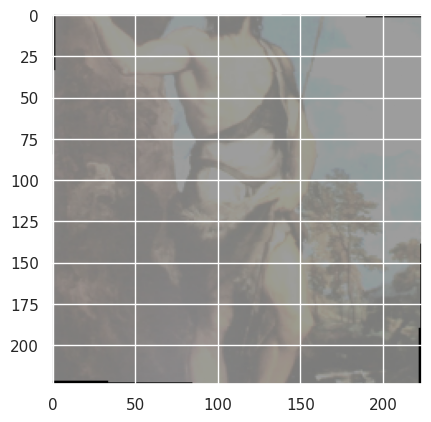

Автор: Rembrandt


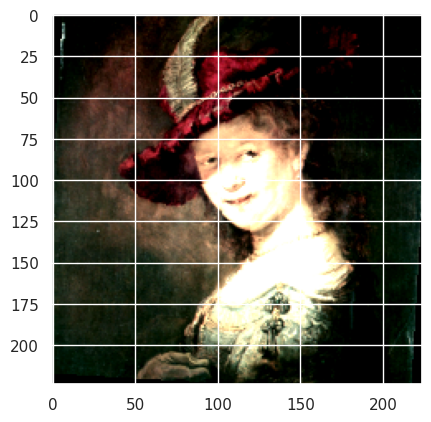

Автор: Titian


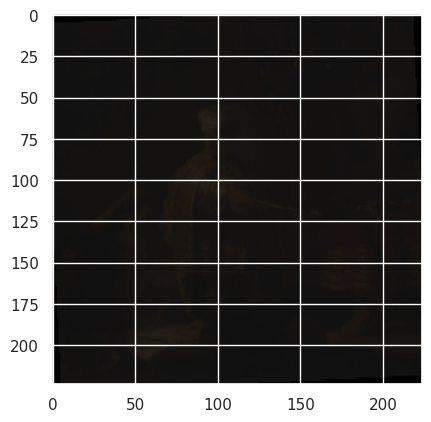

Автор: Rembrandt


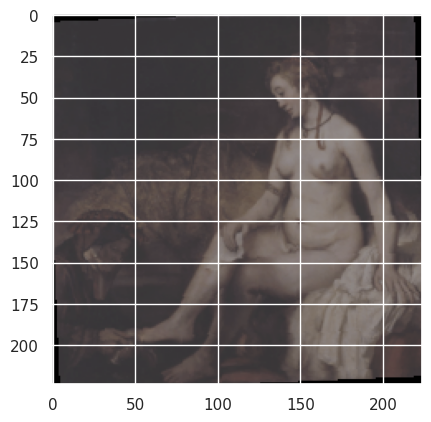

Автор: Titian


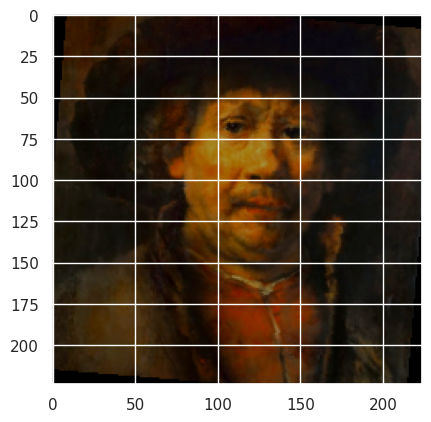

In [ ]:
pics = []
arts = []
it = iter(training_loader)
x_batch, y_batch = next(it)
for i in range(5):
  print('Автор:', train_dataset.classes[y[i]])
  plt.imshow(x_batch[i].permute(1, 2, 0))
  plt.show()

Автор: Rembrandt


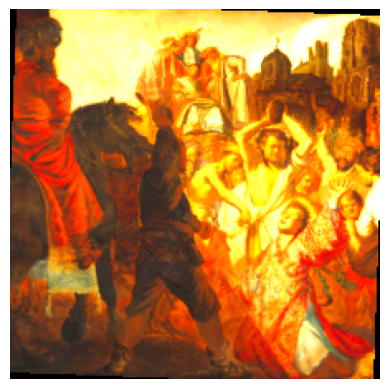

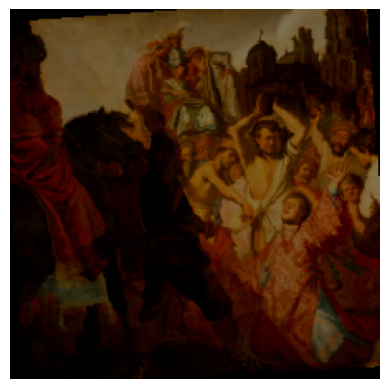

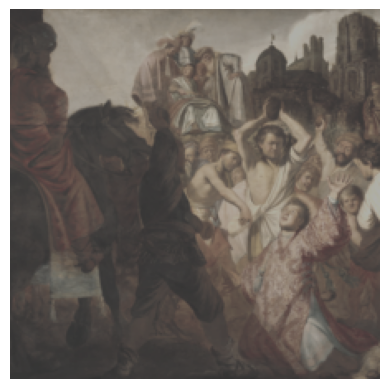

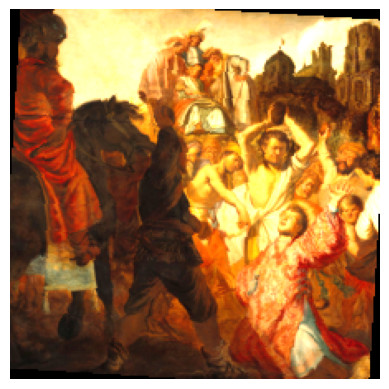

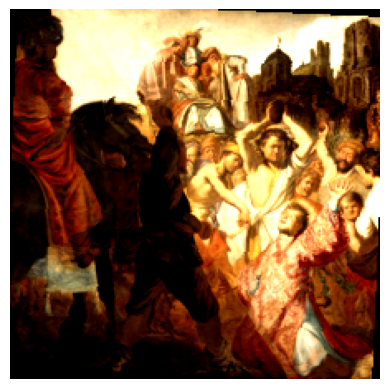

In [ ]:
pics = []
for i in range(5):
  x = next(iter(train_dataset))
  pics.append(x[0].permute(1, 2, 0))
  art = x[1]

print('Автор:', train_dataset.classes[art])
for pic in pics:
  plt.imshow(pic)
  plt.axis('off')
  plt.show()

Выберите лучшую модель. Примените fine-tining модели
 на аугментированных данных. Получается ли улучшить качество?

Теперь наоборот, обучу модель без агументации и сравню с предыдущими

In [ ]:
input_size = 224
selected_artists = artists['name'].tolist()

train_transform = transforms.Compose([
    transforms.Resize(input_size),         # Меняем размер картинки, наименьшая из сторон становится размера input_size
    transforms.CenterCrop(input_size),     # Вырезаем из центра квадрат размера input_size x input_size
    transforms.ToTensor(),                 # Приводим к тензору
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),         # Меняем размер картинки, наименьшая из сторон становится размера input_size
    transforms.CenterCrop(input_size),     # Вырезаем из центра квадрат размера input_size x input_size
    transforms.ToTensor(),                 # Приводим к тензору
])

train_dir = Path(data_path / 'images' / 'train')
val_dir = Path(data_path / 'images' / 'test')

train_dataset = torchvision.datasets.ImageFolder(
    train_dir,
    transform=train_transform,
)

val_dataset = torchvision.datasets.ImageFolder(
    val_dir,
    transform=val_transform,
)

train_indices = [
    i for i, (_, label) in enumerate(train_dataset.samples)
    if train_dataset.classes[label] in selected_artists
]

val_indices = [
    i for i, (_, label) in enumerate(val_dataset.samples)
    if val_dataset.classes[label] in selected_artists
]

new_class_to_idx = {name: i for i, name in enumerate(selected_artists)}

train_samples = [
    (path, new_class_to_idx[train_dataset.classes[label]])
    for path, label in train_dataset.samples
    if train_dataset.classes[label] in selected_artists
]

val_samples = [
    (path, new_class_to_idx[val_dataset.classes[label]])
    for path, label in val_dataset.samples
    if val_dataset.classes[label] in selected_artists
]

train_dataset.samples = train_samples
train_dataset.classes = selected_artists
train_dataset.class_to_idx = new_class_to_idx

val_dataset.samples = val_samples
val_dataset.classes = selected_artists
val_dataset.class_to_idx = new_class_to_idx

train_subset = Subset(train_dataset, range(len(train_dataset.samples)))
val_subset = Subset(val_dataset, range(len(val_dataset.samples)))

In [ ]:
model = FineTunedResNet(n_classes=n_classes, to_freeze=3)

checkpoint_callback = ModelCheckpoint(
    monitor='val_accuracy',
    mode='max',
    dirpath=f'./checkpoints/no_aug',
    filename='epoch={epoch}-val_acc={val_accuracy:.3f}'
)

wandb_logger = WandbLogger(
    project='Artists',
    log_model='all',
    name=f'no_aug',
)

trainer = Trainer(
    logger=wandb_logger,
    callbacks=[log_predictions_callback, checkpoint_callback],
    accelerator='gpu',
    max_epochs=30,
)

torch.cuda.empty_cache()
trainer.fit(model, training_loader, validation_loader)

wandb.finish()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | criterion         | CrossEntropyLoss | 0      | train
1 | feature_extractor | Sequential       | 23.5 M | train
2 | classifier        | Sequential       | 1.1 M  | train
---------------------------------------------------------------
24.6 M    Trainable params
9.5 K     Non-trainable params
24.6 M    Total params
98.251    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (12) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
train_accuracy,▄███▆▁█
train_f1,▁▇▇███████████████████████████
train_loss,█▂▁▁▅▇▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
val_accuracy,▂▁▄▆▆▇▇▆▇▇▇█▇▇▆▇▇█▇▇▇▇▇▇▅▇▇▆▇▆
val_f1,▂▁▄▆▆▇▇▆▇▇▇█▇▇▆▇▇█▇▇▇▇▇▇▅▇▇▆▇▆
val_loss,█▅▃▂▂▁▂▁▁▁▁▁▂▂▃▁▁▁▂▁▁▁▁▂▃▂▂▂▂▂
epoch,29
train_accuracy,1
train_f1,1


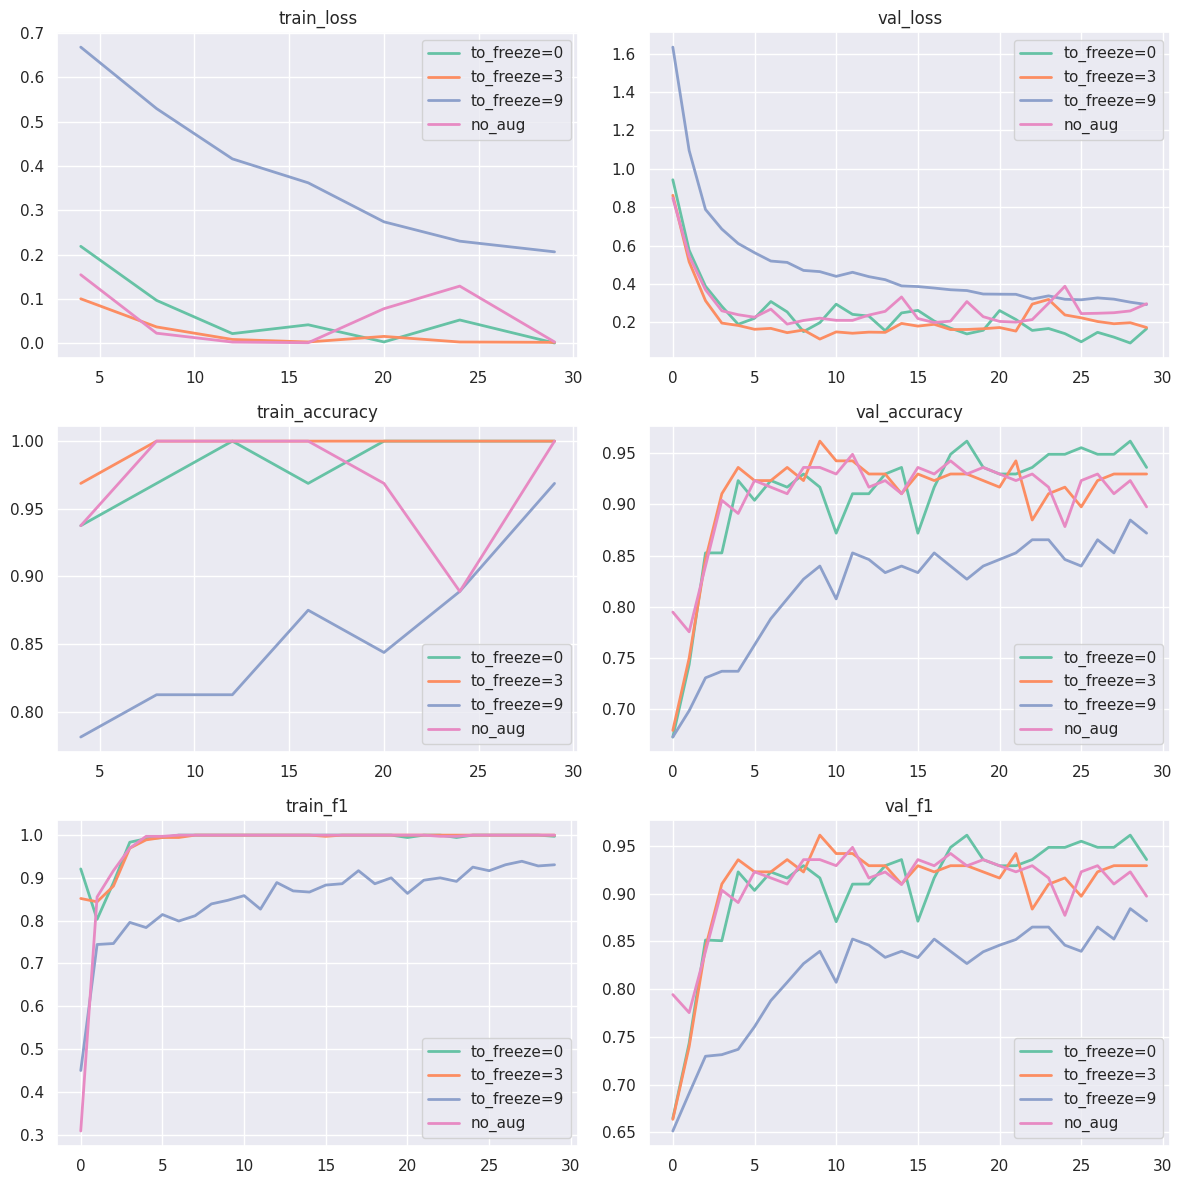

In [ ]:
api = wandb.Api()
runs = api.runs("nekirill2015-/Artists")
subplot_names = [
    ['train_loss', 'val_loss'],
    ['train_accuracy', 'val_accuracy'],
    ['train_f1', 'val_f1']
]

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
lw = 2

for run in runs:
    df = run.history().groupby('epoch').mean(numeric_only=True)
    for i in range(3):
        for j in range(2):
            name = subplot_names[i][j]
            s = df[name].dropna()
            axs[i, j].plot(s.index, s.values, lw=lw, label=run.name)
            axs[i, j].set_title(name)
            axs[i, j].legend()
plt.tight_layout()
plt.show()


**Вывод:** Видим, что лучшие результаты показала полностью размороженная модель. Feature Extractor показала худшие результаты из всех, хотя хорошего качестве достигла в разы быстрее, но недоучилась, малое количество эпох. По наличию аугментации я сравнивал модели с 3 замороженными первыми слоями: лучшей оказаласб модель с аугментацией. Вообще для лучшей оценки нужно обучать на больше эпох

#### 4. Несбалансированность классов
Расширим выборку до всех классов. Примените fine-tuning для расширенной выборки. Хорошо ли модель предсказывает малопредставленные классы?

Для подсчета F1 Score на редких классах после обучения определите у модели метод `test_step` и запустите `trainer.test(model, ...)` (до завершения запуска WandB!). На тесте разрешается записывать метки / предсказания в поля класса.

In [ ]:
artists = pd.read_csv(data_path / 'artists.csv')
artists.head(3)

,name,years,genre,nationality,bio,wikipedia,paintings
0,Amedeo Modigliani,1884 - 1920,Expressionism,Italian,Amedeo Clemente Modigliani (Italian pronunciat...,http://en.wikipedia.org/wiki/Amedeo_Modigliani,193
1,Vasiliy Kandinskiy,1866 - 1944,"Expressionism,Abstractionism",Russian,Wassily Wassilyevich Kandinsky (Russian: Васи́...,http://en.wikipedia.org/wiki/Wassily_Kandinsky,88
2,Diego Rivera,1886 - 1957,"Social Realism,Muralism",Mexican,Diego María de la Concepción Juan Nepomuceno E...,http://en.wikipedia.org/wiki/Diego_Rivera,70


In [13]:
input_size = 224
selected_artists = artists['name'].tolist()

train_transform = transforms.Compose([
    transforms.Resize(input_size),         # Меняем размер картинки, наименьшая из сторон становится размера input_size
    transforms.CenterCrop(input_size),     # Вырезаем из центра квадрат размера input_size x input_size
    transforms.ColorJitter(0.9, 0.9, 0.9), # Меняем случайно цвета
    transforms.RandomAffine(5),            # Применяем случайное аффинное преобразование
    transforms.ToTensor(),                 # Приводим к тензору
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),         # Меняем размер картинки, наименьшая из сторон становится размера input_size
    transforms.CenterCrop(input_size),     # Вырезаем из центра квадрат размера input_size x input_size
    transforms.ToTensor(),                 # Приводим к тензору
])

train_dir = Path(data_path / 'images' / 'train')
val_dir = Path(data_path / 'images' / 'test')

train_dataset = torchvision.datasets.ImageFolder(
    train_dir,
    transform=train_transform,
)

val_dataset = torchvision.datasets.ImageFolder(
    val_dir,
    transform=val_transform,
)

In [18]:
batch_size = 32
n_classes = len(artists['name'])

training_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
model = FineTunedResNet(n_classes=n_classes, to_freeze=3)

checkpoint_callback = ModelCheckpoint(
    monitor='val_accuracy',
    mode='max',
    dirpath=f'./checkpoints/no_aug',
    filename='epoch={epoch}-val_acc={val_accuracy:.3f}'
)

wandb_logger = WandbLogger(
    project='Artists',
    log_model='all',
    name=f'all',
)

trainer = Trainer(
    logger=wandb_logger,
    callbacks=[log_predictions_callback, checkpoint_callback],
    accelerator='gpu',
    max_epochs=30,
)

torch.cuda.empty_cache()
trainer.fit(model, training_loader, validation_loader)

wandb.finish()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | criterion         | CrossEntropyLoss | 0      | train
1 | feature_extractor | Sequential       | 23.5 M | train
2 | classifier        | Sequential       | 1.1 M  | train
---------------------------------------------------------------
24.6 M    Trainable params
9.5 K     Non-trainable params
24.6 M    Total params
98.331    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Недовыполнилось, потому что случился лимит по времени. Попробую рабоатать с тем, что есть: почти всё до посчиталось. Загрузим лучшую сохранённую модель

In [ ]:
api = wandb.Api()
artifact = api.artifact('nekirill2015-/Artists/model-yshmilkp:v8', type='model')
artifact_dir = artifact.download()

wandb: Downloading large artifact 'model-yshmilkp:v8', 281.70MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.2 (1587.1MB/s)


In [ ]:
trainer = Trainer(accelerator="gpu")
ckpt_path = "/content/artifacts/model-yshmilkp:v8/model.ckpt"
model = FineTunedResNet.load_from_checkpoint(ckpt_path, n_classes=n_classes, to_freeze=3)
trainer.test(model, validation_loader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

[{}]

In [ ]:
all_preds = torch.cat(model.test_preds).cpu().numpy()
all_targets = torch.cat(model.test_targets).cpu().numpy()
print(classification_report(all_targets, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9238    0.9798    0.9510        99
           1     0.7927    0.8333    0.8125        78
           2     0.8413    0.9138    0.8760        58
           3     0.8750    0.9333    0.9032        30
           4     0.8462    0.8000    0.8224        55
           5     0.5714    0.4286    0.4898        28
           6     0.7273    0.4706    0.5714        17
           7     0.4545    0.4545    0.4545        22
           8     0.6087    0.6667    0.6364        21
           9     0.6053    0.5897    0.5974        39
          10     0.8636    0.9005    0.8817       211
          11     0.7143    0.3704    0.4878        27
          12     0.6471    0.5238    0.5789        21
          13     0.7812    0.9259    0.8475        27
          14     0.3333    0.1000    0.1538        10
          15     0.7634    0.8068    0.7845        88
          16     0.8889    0.6667    0.7619        36
          17     0.6154    

Видим, что, например, для класса с индексом 14, у которого всего лишь 10 представителей,  имеем f1-score 0.1538, что есть большое отклонение от среднего. Аналогично для 12, 23 и т. д. У классов с большим количеством представителей такой тенденции не наблюдается, значит для мало представленных классов метрика модет сильно занидаться: модель просто игнорирует качество на редких классах, лишний раз закидывая некоторые объекты на более частые метки. При этом для индекса 25, представленного в 8 экземплярах метрика даже лучше среднего

В качестве решения проблемы несбалансированности классов можно взвешивать лосс. Если это [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html), то можно указать в параметре `weight` веса классов. Также можно поменять стратегию семплирования при обучении, для этого можно использовать [WeightedRandomSampler](https://pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler) в качестве параметра `sampler` в `dataloader`. Подумайте, как еще можно можно решить эту проблему. Попробуйте одну из стратегий. Получается ли улучшить качество?

Другим методом может быть аккуратнон создание датасета, используя стратификацию

Проведём небольшой анализ:

In [ ]:
artists

,name,years,genre,nationality,bio,wikipedia,paintings
0,Amedeo Modigliani,1884 - 1920,Expressionism,Italian,Amedeo Clemente Modigliani (Italian pronunciat...,http://en.wikipedia.org/wiki/Amedeo_Modigliani,193
1,Vasiliy Kandinskiy,1866 - 1944,"Expressionism,Abstractionism",Russian,Wassily Wassilyevich Kandinsky (Russian: Васи́...,http://en.wikipedia.org/wiki/Wassily_Kandinsky,88
2,Diego Rivera,1886 - 1957,"Social Realism,Muralism",Mexican,Diego María de la Concepción Juan Nepomuceno E...,http://en.wikipedia.org/wiki/Diego_Rivera,70
3,Claude Monet,1840 - 1926,Impressionism,French,Oscar-Claude Monet (; French: [klod mɔnɛ]; 14 ...,http://en.wikipedia.org/wiki/Claude_Monet,73
4,Rene Magritte,1898 - 1967,"Surrealism,Impressionism",Belgian,René François Ghislain Magritte (French: [ʁəne...,http://en.wikipedia.org/wiki/René_Magritte,194
5,Salvador Dali,1904 - 1989,Surrealism,Spanish,Salvador Domingo Felipe Jacinto Dalí i Domènec...,http://en.wikipedia.org/wiki/Salvador_Dalí,139
6,Edouard Manet,1832 - 1883,"Realism,Impressionism",French,Édouard Manet (US: ; UK: ; French: [edwaʁ manɛ...,http://en.wikipedia.org/wiki/Édouard_Manet,90
7,Andrei Rublev,1360 - 1430,Byzantine Art,Russian,"Andrei Rublev (Russian: Андре́й Рублёв, IPA: [...",http://en.wikipedia.org/wiki/Andrei_Rublev,99
8,Vincent van Gogh,1853 – 1890,Post-Impressionism,Dutch,Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪl...,http://en.wikipedia.org/wiki/Vincent_van_Gogh,877
9,Gustav Klimt,1862 - 1918,"Symbolism,Art Nouveau",Austrian,"Gustav Klimt (July 14, 1862 – February 6, 1918...",http://en.wikipedia.org/wiki/Gustav_Klimt,117


In [ ]:
train_dataset.class_to_idx

{'Albrecht_Durer': 0,
 'Alfred_Sisley': 1,
 'Amedeo_Modigliani': 2,
 'Andrei_Rublev': 3,
 'Andy_Warhol': 4,
 'Camille_Pissarro': 5,
 'Caravaggio': 6,
 'Claude_Monet': 7,
 'Diego_Rivera': 8,
 'Diego_Velazquez': 9,
 'Edgar_Degas': 10,
 'Edouard_Manet': 11,
 'Edvard_Munch': 12,
 'El_Greco': 13,
 'Eugene_Delacroix': 14,
 'Francisco_Goya': 15,
 'Frida_Kahlo': 16,
 'Georges_Seurat': 17,
 'Giotto_di_Bondone': 18,
 'Gustav_Klimt': 19,
 'Gustave_Courbet': 20,
 'Henri_Matisse': 21,
 'Henri_Rousseau': 22,
 'Henri_de_Toulouse-Lautrec': 23,
 'Hieronymus_Bosch': 24,
 'Jackson_Pollock': 25,
 'Jan_van_Eyck': 26,
 'Joan_Miro': 27,
 'Kazimir_Malevich': 28,
 'Leonardo_da_Vinci': 29,
 'Marc_Chagall': 30,
 'Michelangelo': 31,
 'Mikhail_Vrubel': 32,
 'Pablo_Picasso': 33,
 'Paul_Cezanne': 34,
 'Paul_Gauguin': 35,
 'Paul_Klee': 36,
 'Peter_Paul_Rubens': 37,
 'Pierre-Auguste_Renoir': 38,
 'Piet_Mondrian': 39,
 'Pieter_Bruegel': 40,
 'Raphael': 41,
 'Rembrandt': 42,
 'Rene_Magritte': 43,
 'Salvador_Dali': 44,
 

In [ ]:
artists.name.values

array(['Amedeo Modigliani', 'Vasiliy Kandinskiy', 'Diego Rivera',
       'Claude Monet', 'Rene Magritte', 'Salvador Dali', 'Edouard Manet',
       'Andrei Rublev', 'Vincent van Gogh', 'Gustav Klimt',
       'Hieronymus Bosch', 'Kazimir Malevich', 'Mikhail Vrubel',
       'Pablo Picasso', 'Peter Paul Rubens', 'Pierre-Auguste Renoir',
       'Francisco Goya', 'Frida Kahlo', 'El Greco', 'Albrecht Dürer',
       'Alfred Sisley', 'Pieter Bruegel', 'Marc Chagall',
       'Giotto di Bondone', 'Sandro Botticelli', 'Caravaggio',
       'Leonardo da Vinci', 'Diego Velazquez', 'Henri Matisse',
       'Jan van Eyck', 'Edgar Degas', 'Rembrandt', 'Titian',
       'Henri de Toulouse-Lautrec', 'Gustave Courbet', 'Camille Pissarro',
       'William Turner', 'Edvard Munch', 'Paul Cezanne',
       'Eugene Delacroix', 'Henri Rousseau', 'Georges Seurat',
       'Paul Klee', 'Piet Mondrian', 'Joan Miro', 'Andy Warhol',
       'Paul Gauguin', 'Raphael', 'Michelangelo', 'Jackson Pollock'],
      dtype=object)

In [14]:
weights = []
all_sum = 0
for num_painting in artists['paintings']:
    all_sum += num_painting

for name in train_dataset.class_to_idx:
    name = ' '.join(name.split('_'))
    if name == 'Albrecht Durer':
        name = 'Albrecht Dürer'
    weights.append(all_sum / artists[artists['name'] == name]['paintings'].values[0])

In [15]:
weights = torch.Tensor(weights)
weights

tensor([ 25.7500,  32.6100,  43.7617,  85.3131,  46.6630,  92.8132, 153.5636,
        115.6986, 120.6571,  65.9844,  12.0313,  93.8444, 126.0597,  97.0805,
        272.4516,  29.0241,  70.3833, 196.4186,  70.9748,  72.1880, 143.1525,
         45.4086, 120.6571, 104.2716,  61.6496, 351.9167, 104.2716,  82.8039,
         67.0317,  59.0629,  35.3389, 172.3673,  49.3918,  19.2392, 179.7021,
         27.1576,  44.9255,  59.9007,  25.1369, 100.5476,  63.0299,  77.4862,
         32.2366,  43.5361,  60.7626,  51.5000,  33.1216,  95.9773,   9.6306,
        127.9697])

In [16]:
class FineTunedResNet(LightningModule):
    def __init__(self, n_classes, to_freeze = -1, lr = 1e-4):
        '''Инициализация модели
        * to_freeze -- сколько слоев хотим заморозить.
        * n_classes -- кол-во классов'''

        super().__init__()

        self.n_classes = n_classes
        self.criterion = nn.CrossEntropyLoss(weight=weights)
        self.lr = lr
        self.save_hyperparameters()

        backbone = resnet50(weights='ResNet50_Weights.DEFAULT')
        num_filters = backbone.fc.in_features
        layers = list(backbone.children())[:-1]

        n_layers = len(layers) - 1
        if to_freeze > n_layers:
            to_freeze = n_layers
        elif to_freeze < 0:
            to_freeze = 0

        self.feature_extractor = nn.Sequential(*layers)
        for block in self.feature_extractor[:to_freeze]:
          for param in block.parameters():
              param.requires_grad = False

        self.test_preds = []
        self.test_targets = []

        # добавляем 2 FC слоя после выходов предобученной неросети
        self.classifier = nn.Sequential()
        self.classifier.add_module('relu_1', nn.ReLU())
        self.classifier.add_module('fc_1', nn.Linear(num_filters, 512))
        self.classifier.add_module('relu_2', nn.ReLU())
        self.classifier.add_module('fc_2', nn.Linear(512, self.n_classes))

    def forward(self, x):
        '''Forward pass'''

        representations = self.feature_extractor(x).flatten(1)
        out = self.classifier(representations)
        return out

    def training_step(self, batch, batch_idx):
        '''Возвращает лосс с 1 шага обучения по батчу'''

        _, loss, acc = self.__get_preds_loss_accuracy(batch)

        # Логируем лосс и метрику
        self.log('train_loss', loss)
        self.log('train_accuracy', acc)

        return loss

    def validation_step(self, batch, batch_idx):
        '''Используется для логирования метрик'''

        preds, loss, acc = self.__get_preds_loss_accuracy(batch)

        # Логируем лосс и метрику
        self.log('val_loss', loss)
        self.log('val_accuracy', acc)

        # Возвращаем предсказания, чтобы использовать их в callback
        return preds

    def configure_optimizers(self):
        '''Определяет оптимизатор модели'''

        return torch.optim.AdamW(self.parameters(), lr=self.lr)

    def __get_preds_loss_accuracy(self, batch):
        '''Вспомогательная функция для шага обучения / валидации'''

        x, y = batch
        logits = self(x)
        preds = torch.argmax(logits, dim=1)
        loss = self.criterion(logits, y)
        acc = accuracy(preds, y, 'multiclass', num_classes=self.n_classes)
        return preds, loss, acc

    def test_step(self, batch, batch_idx):
        preds, _, _ = self.__get_preds_loss_accuracy(batch)
        _, y = batch
        self.test_preds.append(preds.detach())
        self.test_targets.append(y.detach())

In [19]:
model = FineTunedResNet(n_classes=n_classes, to_freeze=3)

checkpoint_callback = ModelCheckpoint(
    monitor='val_accuracy',
    mode='max',
    dirpath=f'./checkpoints/allW',
    filename='epoch={epoch}-val_acc={val_accuracy:.3f}'
)

wandb_logger = WandbLogger(
    project='Artists',
    log_model='all',
    name=f'allW',
)

trainer = Trainer(
    logger=wandb_logger,
    callbacks=[log_predictions_callback, checkpoint_callback],
    accelerator='gpu',
    max_epochs=30,
)

torch.cuda.empty_cache()
trainer.fit(model, training_loader, validation_loader)

wandb.finish()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | criterion         | CrossEntropyLoss | 0      | train
1 | feature_extractor | Sequential       | 23.5 M | train
2 | classifier        | Sequential       | 1.1 M  | train
---------------------------------------------------------------
24.6 M    Trainable params
9.5 K     Non-trainable params
24.6 M    Total params
98.331    Total estimated model params size (MB)
156       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇█
train_accuracy,▁▂▅▅▅▇▇▇▆▇▇█▇█▇████▇████████████████████
train_f1,▁▄▅▆▇▇████████████████████████
train_loss,█▇▆▅▃▃▃▃▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
val_accuracy,▁▅▇▇▇██████▇███████████████▇██
val_f1,▁▅▇▇▇█████▇████████████████▇██
val_loss,█▃▂▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▃
epoch,29
train_accuracy,1
train_f1,0.99326


Снова недоучилось

<a name=vis></a>
#### 5. Визуализация запусков и выводы



Визуализируйте графики лосса и метрики всех релевантных запусков. Для этого воспользуйтесь `wandb.Api()`, см. семинар. Сравните и сделайте выводы.

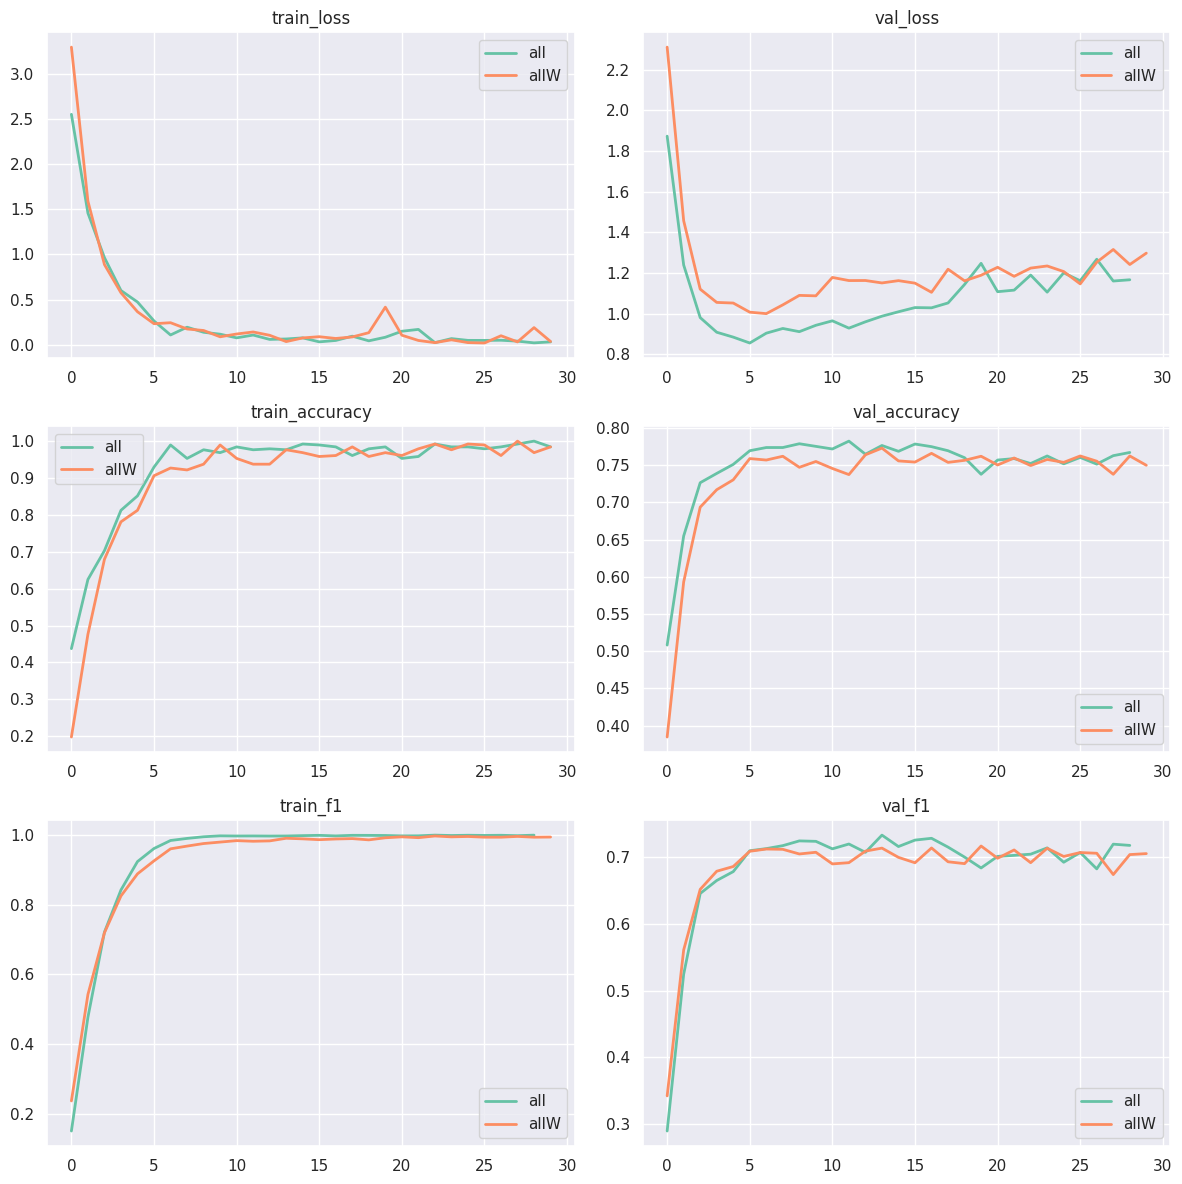

In [20]:
api = wandb.Api()
runs = api.runs("nekirill2015-/Artists")
subplot_names = [
    ['train_loss', 'val_loss'],
    ['train_accuracy', 'val_accuracy'],
    ['train_f1', 'val_f1']
]

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
lw = 2

for run in runs:
    if run.name in ['to_freeze=0', 'to_freeze=3', 'to_freeze=9', 'no_aug']:
        continue
    df = run.history().groupby('epoch').mean(numeric_only=True)
    for i in range(3):
        for j in range(2):
            name = subplot_names[i][j]
            s = df[name].dropna()
            axs[i, j].plot(s.index, s.values, lw=lw, label=run.name)
            axs[i, j].set_title(name)
            axs[i, j].legend()
plt.tight_layout()
plt.show()

Сделайте общий вывод по задаче.

**Вывод:** Предобученные модели позволяют относительно быстро получать хороший результат в сложных задачах

WandB предоставляет удобный функционал для обучения нейронных сетей, автоматически сохраняя чекпоинты, строя графики онлайн, создавая универсальную обёртку над моделями

Аккуратная аугментация позволяет улучшить результаты на тесте, расширяя тренировочный датасет

Дисбаланс классов ведёт к ухудшению метрики, в особенности на редких классах: нужно использовать веса. В моей задаче реализованный подход с весами в кросс-энтропии не сработал

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока